# A/B Test

**META project data:**

*   **Project customer:** IT School "GoIT"
*   **Project name:** Subscription Screen Conversion Optimization (A/B Test)
*   **Project goa:** Conversion analysis, hypothesis testing and presentation of test results
*   **DataSet Name:** [ab_test_data.csv](https://drive.google.com/file/d/1pySA0Ly6TbMMsUPFhbCn7GSiy-vwKiDQ/view?usp=sharing)
*   **Project contractor:** Isachenko Andrii Junior Data Analyst
*   **Tools:**
Python (Pandas, NumPy, MatPlotLib, SeaBorn, Plotly, Statsmodels, SciPy),
Jupyter Notebook
*   **Data received date:** 2026-02-10
*   **Analysis completion date:** 2026-02-14

**Context and problem statement:**<br>A company plans to implement a product update (alternative subscription screen design) to improve the efficiency of the sales funnel. In the mobile application, after onboarding, the user is offered to purchase a weekly subscription for 4.99 USD, which provides access to premium features. It was decided to test an alternative design of the subscription registration screen, which offers to purchase a subscription for 4.99 USD, but indicates that it is at a 50% discount.<br><br>**The hypotheses that will be tested in this test are formulated:**<br>
**Null hypothesis (H0):** The new design of the subscription purchase screen does not affect the user in any way, and the conversion rate from user to subscriber will be within the baseline performance.

**Alternative hypothesis (H1):** Implementing a new subscription purchase screen design that highlights a 50% benefit (while maintaining the price of 4.99 USD) will increase the conversion rate from user to subscriber.<br><br>**Two groups are formed:**<br>
**Group A (Control)** — sees the current screen with a subscription of 4.99 USD.<br>
**Group B (Experimental)** — sees a screen with a subscription of 4.99 USD, but with the label "50% off".<br><br>New users of the application who go through the onboarding process and reach the screen with the subscription offer participate.
We exclude those who have already seen the screen or have an active subscription. The distribution of people to groups A or B is random. This will help to avoid systematic sampling errors and ensure that the groups are comparable on all characteristics except the tested change.<br><br>**Selected target metric:**<br>**Conversion Rate** - conversion to subscription.<br>Current conversion rate CR = 6.1%<br>Minimum expected increase in conversion Minimum Detectable Effect (MDE) = 1.5% (absolute increase)<br>Expected conversion for group B = 7.6%<br>Confidence level = 95%<br>Power level = 80%<br><br>**Main problem**<br>It is necessary to objectively assess whether the changes made (Option B) have led to a statistically significant increase in the conversion rate compared to the current version (Option A), or whether the observed difference is the result of random fluctuations data.<br><br>**Key business questions:**<br>1. **Effectiveness:** Does Option B provide a conversion gain that justifies the development and implementation costs?<br>2. **Reliability:** How likely is it that the positive effect obtained will persist after scaling to all users?<br>3. **Stability:** How did the metric behave during the test? Was it prone to anomalous spikes on certain days?<br><br>**Analysis Objective:**<br>• Conduct a full cycle of statistical hypothesis testing.<br>• Calculate 95% confidence intervals to accurately estimate the range of possible effects.<br>• Provide a final business recommendation on whether to roll out the update or not.<br><br>**Expected Result:**<br><br>
A well-founded conclusion on the success of the test, visualized using probability distributions and dynamics graphs, which will allow management to make Data-Driven decisions.<br><br>*To minimize risks and make an informed decision, A/B testing was conducted for 21 days.<br><br>

**Let's move on to A/B testing**

**0. Importing libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import norm
import matplotlib.ticker as mtick
import statsmodels.stats.api as sms
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

**1. Calculating the minimum sample size required to test hypotheses**

In [2]:
# We define the input parameters
baseline_cr = 0.061  # Current conversion (6.1%)
mde = 0.015          # Minimum Detectable Effect (we wanted to see an increase of at least 1.5%)
expected_cr = baseline_cr + mde # Expected conversion for group B (7.6%)

# Calculating Effect Size for Proportions
# Cohen's h — it is a standardized measure of the difference between two shares
effect_size = sms.proportion_effectsize(baseline_cr, expected_cr)

# Calculating the required sample size
sample_size = sms.NormalIndPower().solve_power(
    effect_size=effect_size,
    power=0.8,       # Power (80%) is the standard in analytics
    alpha=0.05,      # Significance level (5%)
    ratio=1          # Group ratio 1:1
)

print(f"--- Pre-test analysis results ---")
print(f"Basic conversion: {baseline_cr:.2%}")
print(f"The minimum effect (MDE) we want to capture: {mde:.2%}")
print(f"Required number of users per ONE group: {round(sample_size)}")
print(f"Total quantity for the test: {round(sample_size) * 2}")

--- Pre-test analysis results ---
Basic conversion: 6.10%
The minimum effect (MDE) we want to capture: 1.50%
Required number of users per ONE group: 4439
Total quantity for the test: 8878


**2. Data loading**

In [3]:
# Connect the dataset
df_url = '/content/ab_test_data.csv'
df = pd.read_csv(df_url)

# Checking the data
df.head()

,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0


**3. Data Cleaning**

In [4]:
# Data loading
df = pd.read_csv('ab_test_data.csv')

# --- STAGE 1: Initial state ---
total_cells_before = df.size # Number of all cells (rows * columns)
rows_before = len(df)
print(f"--- Initial statistics ---")
print(f"Total number of cells to be processed: {total_cells_before}")
print(f"Number of lines: {rows_before}")

# --- STEP 2: Removing spaces ---
# Remove spaces at the beginning and end of lines in text columns (user_id, test_group)
df['user_id'] = df['user_id'].astype(str).str.strip()
df['test_group'] = df['test_group'].astype(str).str.strip()
print("\n[OK] Spaces in text columns removed.")

# --- STEP 3: Check for empty values (Missing Values) ---
missing_values = df.isnull().sum().sum()
print(f"\n--- Check for gaps ---")
print(f"Empty cells found: {missing_values}")
if missing_values > 0:
    df = df.dropna()
    print("Empty cells removed.")

# --- STEP 4: Check for duplicates ---
# Check for duplicates by user_id (one user cannot be in the system twice)
duplicates_count = df.duplicated(subset=['user_id']).sum()
print(f"\n--- Check for duplicates ---")
print(f"Duplicates found (по user_id): {duplicates_count}")

if duplicates_count > 0:
    df = df.drop_duplicates(subset=['user_id'], keep='first')
    print("Duplicates removed (first occurrences kept).")

# --- STAGE 5: Processing Results ---
rows_after = len(df)
total_cells_after = df.size
deleted_rows = rows_before - rows_after

print(f"\n--- Final cleanup statistics ---")
print(f"Deleted lines: {deleted_rows}")
print(f"Total number of cells after cleaning: {total_cells_after}")

# --- STEP 6: Saving the cleaned file ---
df.to_csv('ab_test_data_cleaned.csv', index=False)
print("\n[SUCCESS] The cleaned dataset was saved to a file: 'ab_test_data_cleaned.csv'")

--- Initial statistics ---
Total number of cells to be processed: 79992
Number of lines: 19998

[OK] Spaces in text columns removed.

--- Check for gaps ---
Empty cells found: 0

--- Check for duplicates ---
Duplicates found (по user_id): 0

--- Final cleanup statistics ---
Deleted lines: 0
Total number of cells after cleaning: 79992

[SUCCESS] The cleaned dataset was saved to a file: 'ab_test_data_cleaned.csv'


**4. Calculate the number of users in groups A and B**

In [5]:
# Get the number of users for each group
user_counts = df['test_group'].value_counts()

# Output separately for each group
users_a = user_counts['a']
users_b = user_counts['b']

print(f"Number of users in group A: {users_a}")
print(f"Number of users in group B: {users_b}")

Number of users in group A: 10013
Number of users in group B: 9985


**5. Calculate the number of conversions in groups A and B**

In [6]:
# Sum the conversion column (since there are 1 and 0, the sum will equal the number of conversions)
conversions = df.groupby('test_group')['conversion'].sum()

# Output separately for each group
conv_a = conversions['a']
conv_b = conversions['b']

print(f"Number of conversions in the group A: {conv_a}")
print(f"Number of conversions in the group B: {conv_b}")

Number of conversions in the group A: 611
Number of conversions in the group B: 889


**6. Calculate the conversion rate in groups A and B**

In [7]:
# Calculate the average conversion value for each group
conversion_rates = df.groupby('test_group')['conversion'].mean()

# Output separately, formatting as percentages
print(f"Group A conversion rate: {conversion_rates['a']:.2%}")
print(f"Group B conversion rate: {conversion_rates['b']:.2%}")

Group A conversion rate: 6.10%
Group B conversion rate: 8.90%


**7. We determine the start date and end date of the test, as well as the duration of the test in days.**

In [14]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
# Find the start and end date
start_date = df['timestamp'].min()
end_date = df['timestamp'].max()

# Calculate the duration
# .days returns the net number of days
duration = (end_date - start_date).days

# We output separately
print(f"Test start date: {start_date.date()}")
print(f"Test end date: {end_date.date()}")
print(f"Test duration: {duration} days")

Test start date: 2023-07-03
Test end date: 2023-07-25
Test duration: 21 days


**8. To analyze the results of the A/B test, we will use the Z-test as the main one, and the T-test as an additional one.**<br><br>**Z-test (Proportions)**<br>Since our main metric is Conversion Rate (binary value: 0 or 1), the Z-test for proportions (Proportions Z-test) is a classic choice.<br>**Reason:** It is designed specifically for comparing proportions in large samples.<br>**Goal:** To check whether the difference between proportions of 6.1% and 8.9% is statistically significant.<br><br>**T-test (Mean values)**<br>Although the T-test is more often used for continuous values ​​(e.g., order receipt), we use the Independent T-test (Student's test) as an additional check.<br>**Reason:** The T-test is more "conservative". It better accounts for the variance (scatter) of the data and is robust to outliers.<br>**Goal:** Obtain confirmation of the results by another mathematical method. For large amounts of data ($N > 30$), the T-distribution approaches the normal (Z), so the results should match.

In [9]:
# Calculation of required values
n_a = df[df['test_group'] == 'a']['conversion'].count()
n_b = df[df['test_group'] == 'b']['conversion'].count()
s_a = df[df['test_group'] == 'a']['conversion'].sum()
s_b = df[df['test_group'] == 'b']['conversion'].sum()

cr_a = s_a / n_a
cr_b = s_b / n_b

# Statistical test via SciPy
# Calculating the Z-statistic manually (two-proportion formula)
pooled_prob = (s_a + s_b) / (n_a + n_b)
pooled_se = np.sqrt(pooled_prob * (1 - pooled_prob) * (1/n_a + 1/n_b))
z_stat = (cr_b - cr_a) / pooled_se

# Getting p-value via SciPy normal distribution (two-tailed test)
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f"RESULT OF STATISTICAL ANALYSIS:")
print(f"Z-test: {z_stat:.4f}")
print(f"p-value: {p_value:.14f}")


alpha = 0.05
if p_value < 0.05:
    print(f"Conclusion: Since the p-value < {alpha}. We REJECT the null hypothesis H0). The difference between the groups is statistically significant.")
else:
    print(f"Conclusion: p-value >= {alpha}. We CANNOT reject the null hypothesis.")

RESULT OF STATISTICAL ANALYSIS:
Z-test: 7.5197
p-value: 0.00000000000005
Conclusion: Since the p-value < 0.05. We REJECT the null hypothesis H0). The difference between the groups is statistically significant.


Statistical significance: The resulting p-value is significantly less than the critical level of 0.05. This means that the observed increase in conversion in group B is not a random fluctuation, but the result of the changes made (adding the discount information).

**For additional verification, we will also conduct a T-test**

In [10]:
# Splitting the data into two samples
group_a = df[df['test_group'] == 'b']['conversion']
group_b = df[df['test_group'] == 'a']['conversion']

# We specify the indicator 'b' in group_a, since according to the instructions we should specify the planned, increasing indicator first

# Performing a t-test (Independent Two-Sample Test)
# equal_var=False is used for Welch's t-test,
# which is safer if the group variances are different
t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)

# Outputting results
print("--- Результати T-тесту ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.15f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("\nConclusion: The difference is statistically significant (we reject H0)")
else:
    print("\nConclusion: The difference is random (failed to reject H0)")

--- Результати T-тесту ---
T-statistic: 7.5281
P-value: 0.000000000000054

Conclusion: The difference is statistically significant (we reject H0)


**9. Build a visualization to compare average conversion values ​​in groups A and B**

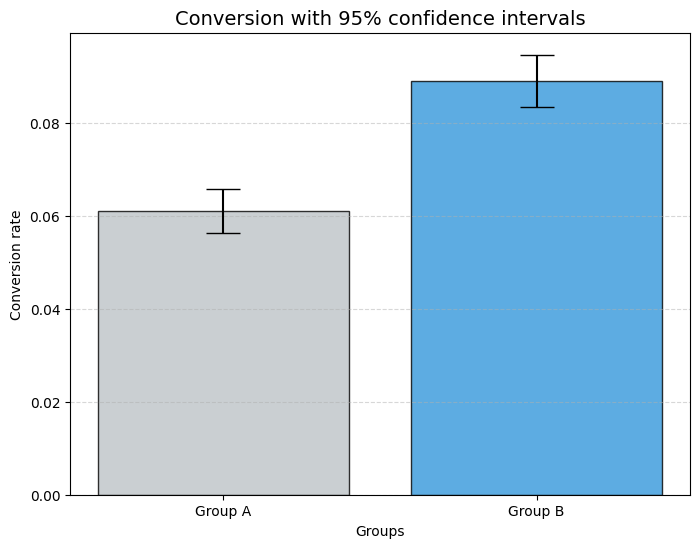

In [11]:
# Visualization with confidence intervals (SciPy)

# We use the variables we calculated earlier:
# n_a, n_b — number of users
# s_a, s_b — number of conversions
# cr_a, cr_b — conversion rate

# Calculating the Z-score for a 95% confidence interval
z_critical = stats.norm.ppf(0.975)

# Function for calculating the interval manually
def calculate_ci(p, n, z):
    se = np.sqrt(p * (1 - p) / n)
    return p - z * se, p + z * se

ci_a_lower, ci_a_upper = calculate_ci(cr_a, n_a, z_critical)
ci_b_lower, ci_b_upper = calculate_ci(cr_b, n_b, z_critical)

# Preparing data for the graph
groups = ['Group A', 'Group B']
means = [cr_a, cr_b]
# Errors (distance from the mean to the limits of the interval)
errors = [
    [cr_a - ci_a_lower, cr_b - ci_b_lower], # lower limit
    [ci_a_upper - cr_a, ci_b_upper - cr_b]  # upper limit
]

plt.figure(figsize=(8, 6))
plt.bar(groups, means, yerr=errors, capsize=12, color=['#bdc3c7', '#3498db'], alpha=0.8, edgecolor='black')

plt.title('Conversion with 95% confidence intervals', fontsize=14)
plt.xlabel('Groups')
plt.ylabel('Conversion rate')

plt.grid(axis='y', linestyle='--', alpha=0.5)

# Save the result as png
plt.savefig('ab_test_viz.png', dpi=300, bbox_inches='tight')
plt.show()


**Conclusion:** The chart clearly shows that the conversion in group B is higher. This indicates that the advertising is effective and users who see the discount information subscribe more often. The “whiskers” on the chart (confidence intervals) indicate that the lower limit of group B’s conversion is still higher than the upper limit of group A. This confirms that the increase is reliable.

**Let's additionally plot the probability distribution density**

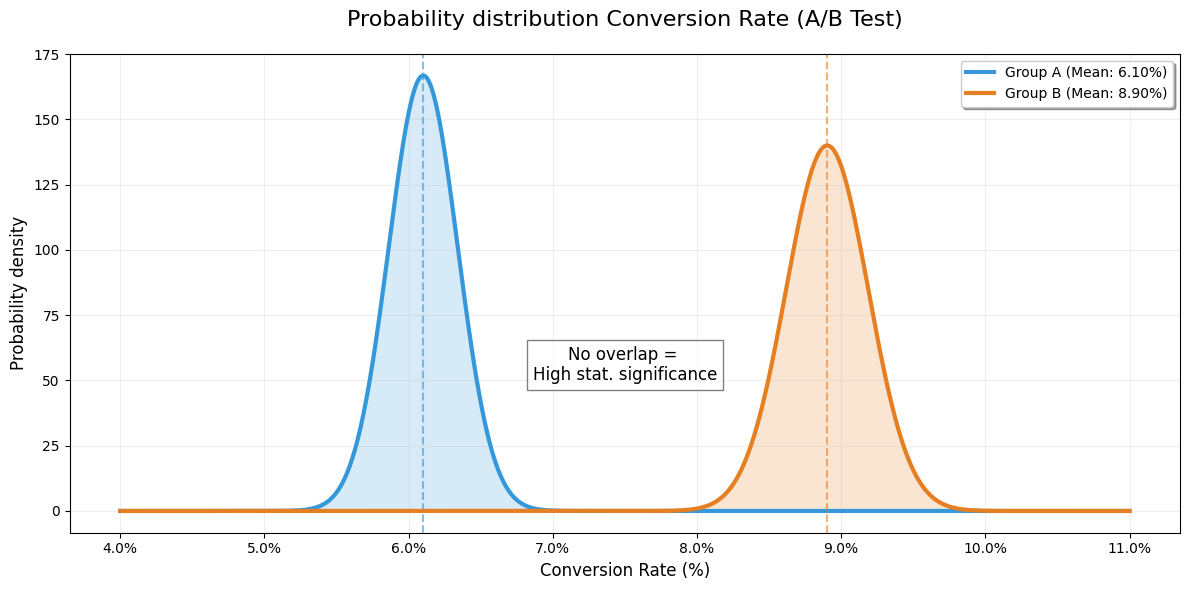

In [12]:
# Calculation of parameters for groups
stats_summary = df.groupby('test_group')['conversion'].agg(['mean', 'std', 'count'])
stats_summary['se'] = stats_summary['std'] / np.sqrt(stats_summary['count'])

# Graph construction
plt.figure(figsize=(12, 6))

# Create a range x (from 4% to 11%)
x = np.linspace(0.04, 0.11, 1000)

for group in ['a', 'b']:
    mean = stats_summary.loc[group, 'mean']
    se = stats_summary.loc[group, 'se']

    # Distribution curve generation
    y = norm.pdf(x, mean, se)

    color = '#3498db' if group == 'a' else '#e67e22'
    label = f'Group {group.upper()} (Mean: {mean:.2%})'

    plt.plot(x, y, label=label, lw=3, color=color)
    plt.fill_between(x, 0, y, alpha=0.2, color=color)
    plt.axvline(mean, color=color, linestyle='--', alpha=0.6)

# Format the X axis as a percentage
ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Design
plt.title('Probability distribution Conversion Rate (A/B Test)', fontsize=16, pad=20)
plt.xlabel('Conversion Rate (%)', fontsize=12)
plt.ylabel('Probability density', fontsize=12)
plt.legend(frameon=True, shadow=True, loc='upper right')
plt.grid(axis='both', alpha=0.2)

plt.tight_layout()
# Let's add a note about the significance
plt.text(0.075, 50, 'No overlap = \nHigh stat. significance',
         bbox=dict(facecolor='white', alpha=0.5), ha='center', fontsize=12)

# Save the result as png
plt.savefig('conversion_distribution.png', dpi=300, bbox_inches='tight')

plt.show()

The probability density graph demonstrates the statistical separation of the control and test samples. The almost complete absence of overlap between the "bells" of groups A and B indicates an extremely low p-value and high power of the test.

**10. We build a graph of conversion changes over the A/B test period**

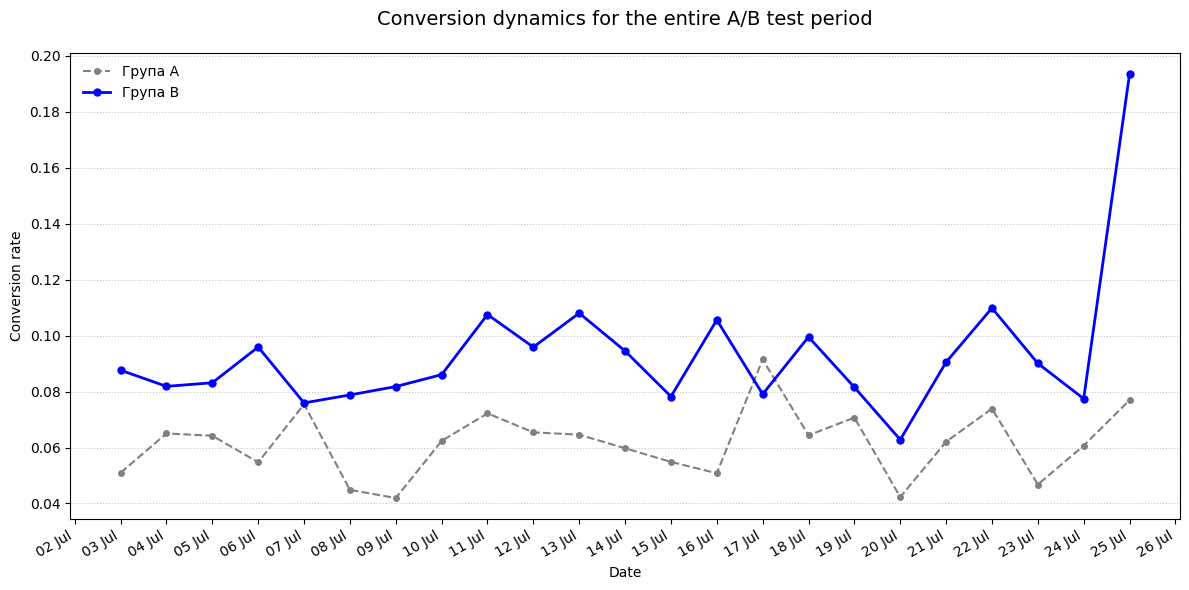

In [13]:
df['date'] = df['timestamp'].dt.date
# Daily conversion calculation
daily_cr = df.groupby(['date', 'test_group'])['conversion'].mean().unstack()

# Graph construction
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(daily_cr.index, daily_cr['a'], label='Група A',
        color='gray', marker='o', linestyle='--', markersize=4)
ax.plot(daily_cr.index, daily_cr['b'], label='Група B',
        color='blue', marker='o', linewidth=2, markersize=5)

# Set the date format (Day Month)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

#Set the interval (show the date every day)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

# Automatically skew and align dates
fig.autofmt_xdate()

# Additional design
ax.set_title('Conversion dynamics for the entire A/B test period', fontsize=14, pad=20)
plt.xlabel('Date')
ax.set_ylabel('Conversion rate')
ax.grid(True, axis='y', linestyle=':', alpha=0.7)
ax.legend(frameon=False)

# We save the dynamics graph.
plt.savefig('conversion_dynamics.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

**Analytical conclusions**

**Context and results:** A test lasting more than 20 days was conducted. During this period, a sufficient sample was collected (almost 20,000 users each).<br>
**Result details:** Group B demonstrated a conversion of 8.90%, while control group A — 6.10%. There is a relative increase in conversion of ~46%.<br>**A combined approach was used to analyze the results**.<br>Z-test was used as the main method for comparing conversion rates. Additionally, a T-test was conducted, which does not require equality of variances in the groups. Obtaining identical results (P-value < 0.05) by both methods confirms the high reliability of our conclusions and excludes a mathematical error associated with the choice of the distribution model.<br>
**Statistical confirmation:**<br>**The Z-test used showed** the p-value: 0.000000000000005 . Since this value is significantly less than the critical level (0.05
), and the Z-statistic value: 7.52, which is significantly higher than the critical value (which is usually 1.96), we have every reason to believe that the availability of information about the "50% discount" really affects the user's decision to subscribe.<br>**The T-test used also showed** the obtained value $p \approx 0$ (much less than the threshold level $\alpha = 0.05$) indicates that the difference between the groups is not random. The changes in Option B have a real impact on user behavior. The average conversion rate increased from 6.1% to 8.9%. This is an absolute increase of 2.8% (or a relative increase of +45.9%).<br>
**Visual interpretation:** The confidence interval graph (Graph 1) shows that the lower limit of Group B is above the upper limit of Group A. This indicates a high reliability of the result. This is also visually confirmed by the probability density graph (Graph 2). The cumulative graph (Graph 3) shows that Group B was consistently in the lead throughout most of the test.<br>
**Recommendation:** The test result is positive. Hypothesis H1 is confirmed by the test results. It is recommended to implement the new design (with discount information) for all users.